## Impotações e configuração de ambiente

In [1]:
# Environment setup

import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    ENV = "colab"
    print("Running on Google Colab")
else:
    ENV = "local"
    print("Running locally")


Running locally


In [2]:
if ENV == "colab":

    print("Install dependencies")
    !pip install -q pytorch-msssim torchsummary

    # Library Imports
    import time
    from scipy import ndimage
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    import random
    import seaborn as sns
    import sys
    import struct
    from scipy import interpolate
    import torch
    import torch.nn as nn
    from pytorch_msssim import ssim
    from torch.utils.data import Dataset
    from sklearn.model_selection import train_test_split
    from torch.utils.data import DataLoader
    from torch.optim import Adam

else:

    # Library Imports
    import time
    from scipy import ndimage
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    import random
    import seaborn as sns
    import sys
    import struct
    from scipy import interpolate
    import torch
    import torch.nn as nn
    from pytorch_msssim import ssim
    from torch.utils.data import Dataset
    from sklearn.model_selection import train_test_split
    from torch.utils.data import DataLoader
    from torch.optim import Adam

## Importação dos dados

In [3]:
shot_size = (1000,70) #tamanho dos tiros
img_size = (70,70) #tamanho das imagens
n_filters = 5 #número de tiros

In [4]:
root_dir = "../data"

for root, dirs, files in os.walk(root_dir):
    print(root)
    for f in files:
        print("   ", f)

../data
../data/FlatFault
../data/FlatFault/FlatFault_B
    seis8_1_0.npy
    vel8_1_0.npy
    seis6_1_0.npy
    vel6_1_0.npy
../data/FlatFault/FlatFault_A
    vel2_1_0.npy
    seis4_1_0.npy
    vel4_1_0.npy
    seis2_1_0.npy
../data/FlatVel
../data/FlatVel/FlatVel_B
../data/FlatVel/FlatVel_B/model
    model2.npy
    model1.npy
../data/FlatVel/FlatVel_B/data
    data2.npy
    data1.npy
../data/FlatVel/FlatVel_A
../data/FlatVel/FlatVel_A/model
    model2.npy
    model1.npy
../data/FlatVel/FlatVel_A/data
    data2.npy
    data1.npy


In [5]:
from pathlib import Path

root = Path("../data")

shot_files = []
model_files = []

# LOADING PATHS
for file in root.rglob("*.npy"):
    name = file.name.lower()

    # arquivos de tiros
    if name.startswith("data") or name.startswith("seis"):
        shot_files.append(str(file))

    # arquivos de velocidade/modelo
    elif name.startswith("model") or name.startswith("vel"):
        model_files.append(str(file))

shot_files = sorted(shot_files)
model_files = sorted(model_files)

print("shots:", len(shot_files))
print("models:", len(model_files))

shots: 8
models: 8


In [6]:
# LOADING IMAGES

x_list = []
y_list = []

for shot_path, model_path in zip(shot_files, model_files):

    ent = np.load(shot_path)      # (500,5,1000,70)
    sai = np.load(model_path)     # (500,1,70,70)

    x_list.append(ent)
    y_list.append(sai)

x_data = np.concatenate(x_list, axis=0)
y_data = np.concatenate(y_list, axis=0)

print(x_data.shape)
print(y_data.shape)

(4000, 5, 1000, 70)
(4000, 1, 70, 70)


In [7]:
def normalize_function(img):
    imag = img
    vis_p_max = np.percentile(imag, 96)
    vis_p_min = -np.percentile(imag, 96)
    clip=(vis_p_max - vis_p_min)/2
    imag = np.clip(imag,-clip,clip)
    imag=(imag+clip)/(2*clip)
    return imag

In [8]:
for filt in range(n_filters):
    x_data[:, filt,:, :] = normalize_function(x_data[:, filt,:, :])
y_data=y_data/1000 # trata a velocidade como km/s, range de saída menor

In [9]:
np.amin(y_data)

np.float32(1.5)

In [10]:
y_datan=(y_data-np.amin(y_data))
y_data=y_datan/np.amax(y_datan)

In [11]:
np.amin(y_datan)

np.float32(0.0)

In [12]:
def plot_shot_gather(shot_tensor, sample_idx, shot_idx=0, path=None):
    """
    Plota um shot gather do OpenFWI.

    Parameters
    ----------
    shot_tensor : ndarray
        Tensor de tiros com shape (N, 5, 1000, 70)
    sample_idx : int
        Índice da amostra.
    shot_idx : int
        Índice da fonte (0 a 4).
    path : str, optional
        Caminho para salvar a figura.
    """

    gather = shot_tensor[sample_idx, shot_idx]

    fig, ax = plt.subplots(figsize=(6,4))

    im = ax.imshow(
        gather,
        cmap="gray",
        aspect="auto",
        origin="upper"
    )

    ax.set_xlabel("Receiver")
    ax.set_ylabel("Time Sample")
    ax.set_title(f"Sample {sample_idx} - Shot {shot_idx}")

    plt.colorbar(im, ax=ax, label="Amplitude")

    if path is not None:
        plt.savefig(path, dpi=300, bbox_inches="tight")

    plt.show()

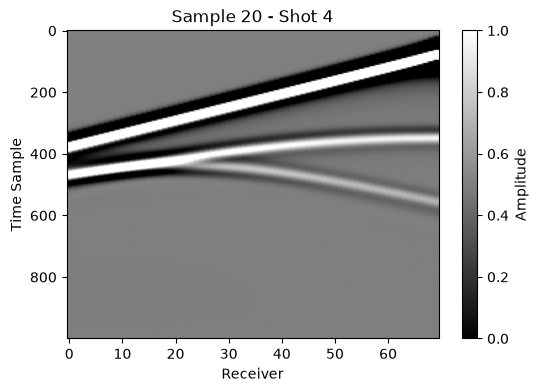

In [13]:
plot_shot_gather(x_data, sample_idx=20, shot_idx=4, path=None)

In [14]:
def plot_velocity_model(model_tensor, sample_idx, path=None):
    """
    Plota o mapa de velocidade de um sample específico com os eixos baseados na geometria real.
    
    Parameters:
    - model_tensor: O tensor completo de velocidades (ex: shape 500, 1, 70, 70)
    - sample_idx: O índice do modelo que você deseja plotar (de 0 a 499)
    - path: Caminho para salvar a imagem (opcional)
    - rainbow_cmap: Colormap para o plot (padrão 'jet')
    """

    # Load colormap for velocity map visualization
    from matplotlib.colors import ListedColormap
    rainbow_cmap = ListedColormap(np.load('../geometria_aquisicao/rainbow256.npy'))

    # 1. Extrai o sample e remove as dimensões extras para ficar 2D (70, 70)
    label = np.squeeze(model_tensor[sample_idx])
    
    plt.rcParams.update({'font.size': 16})
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    
    vmax, vmin = np.max(label), np.min(label)
    im = ax.matshow(label, cmap=rainbow_cmap, vmin=vmin, vmax=vmax)

    # Dimensões da tabela
    grid_spacing = 10       # 10 metros por pixel
    max_distance = 700      # 0.7 km = 700 metros
    tick_step_meters = 140  # Passo dos ticks em metros (ex: 0, 140, 280...)
    
    # Conversão de metros para índices da matriz (pixels)
    tick_step_pixels = tick_step_meters / grid_spacing # 140 / 10 = 14 pixels
    max_pixels = label.shape[0]                        # 70 pixels
    
    # Criando a lista de posições (pixels) e labels (metros)
    ticks_pixels = np.arange(0, max_pixels + 1, tick_step_pixels)
    ticks_meters = np.arange(0, max_distance + 1, tick_step_meters)
    
    # Configuração dos eixos
    ax.set_aspect(aspect=1)
    ax.set_xticks(ticks_pixels)
    ax.set_xticklabels(ticks_meters)
    ax.set_yticks(ticks_pixels)
    ax.set_yticklabels(ticks_meters)
    
    # Títulos e legendas
    ax.set_title('Distance (m)', y=1.08)
    ax.set_ylabel('Depth (m)', fontsize=18)

    fig.colorbar(im, ax=ax, shrink=1.0, label='Velocity (m/s)')
    
    if path:
        plt.savefig(path, bbox_inches='tight')
        print(f"Imagem salva em: {path}")
    
    plt.show()

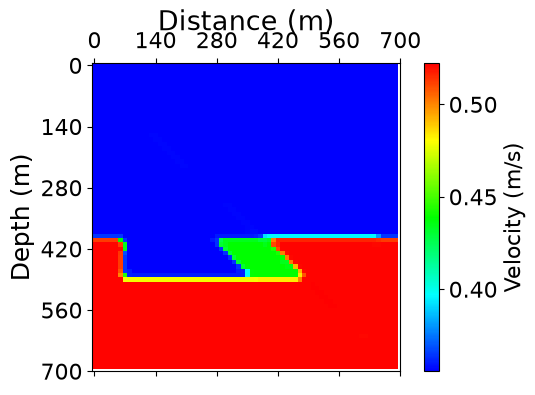

In [15]:
plot_velocity_model(y_data, sample_idx=10, path=None)

In [16]:
np.amax(y_data)

np.float32(1.0)

In [17]:
EPOCAS=150
BATCH = 8
PATIENCE = 25

## Arquiteturas

In [18]:
class Conv2dBlock(nn.Module):
    def __init__(self, in_channels, out_channels,
                 kernel_size=3,
                 batchnorm=True,
                 momentum=0.9):
        super().__init__()
        layers = []
        layers.append(
            nn.Conv2d(in_channels,out_channels,kernel_size=kernel_size,padding="same",bias=not batchnorm)
        )

        if batchnorm:
            layers.append(
                nn.BatchNorm2d(out_channels,momentum=1 - momentum)
            )

        layers.append(nn.ReLU(inplace=True))
        layers.append(
            nn.Conv2d(out_channels,out_channels,kernel_size=kernel_size,padding="same",bias=not batchnorm)
        )
        if batchnorm:
            layers.append(
                nn.BatchNorm2d(out_channels,momentum=0.1)
            )

        layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [43]:
import torch.nn.functional as F

class UNetUpConv(nn.Module):
    def __init__(
        self,
        in_channels=1,
        output_filters=1,
        n_filters=16,
        dropout=0.2,
        batchnorm=True,
        moment=0.9
    ):
        super().__init__()

        # Encoder
        self.c1 = Conv2dBlock(in_channels,n_filters,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c2 = Conv2dBlock(n_filters,n_filters * 2,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c3 = Conv2dBlock(n_filters * 2,n_filters * 4,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c4 = Conv2dBlock(n_filters * 4,n_filters * 8,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c5 = Conv2dBlock(n_filters * 8,n_filters * 16,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(dropout)

        # Decoder
        # self.up6 = nn.ConvTranspose2d(n_filters * 16,n_filters * 16,kernel_size=3,stride=2, padding=1,output_padding=1)
        self.up6 = nn.ConvTranspose2d(n_filters * 16, n_filters * 16, kernel_size=2, stride=2, padding=0, output_padding=0)

        self.up7 = nn.ConvTranspose2d(n_filters * 8, n_filters * 8, kernel_size=2, stride=2, padding=0, output_padding=1)

        self.up8 = nn.ConvTranspose2d(n_filters * 4, n_filters * 4, kernel_size=2, stride=2, padding=0, output_padding=1)

        # self.up9 = nn.ConvTranspose2d(n_filters * 2,n_filters*2,kernel_size=3,stride=2,padding=1,output_padding=1)
        self.up9 = nn.ConvTranspose2d(n_filters * 2, n_filters * 2, kernel_size=2, stride=2, padding=0, output_padding=0)

        self.c6 = Conv2dBlock(n_filters * 16+n_filters * 8,n_filters * 8,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c7 = Conv2dBlock(n_filters * 8+n_filters * 4,n_filters * 4,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c8 = Conv2dBlock(n_filters * 4+n_filters * 2,n_filters * 2,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c9 = Conv2dBlock(n_filters * 2+n_filters,n_filters,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.out = nn.Conv2d(n_filters,output_filters,kernel_size=1)

    def forward(self, x):

        # Transforma de 70x70 para 80x80 usando replicação das bordas
        # pad=(esquerda, direita, cima, baixo)
        # x = F.pad(x, pad=(5, 5, 5, 5), mode='replicate')

        c1 = self.c1(x)
        p1 = self.drop(self.pool(c1))

        c2 = self.c2(p1)
        p2 = self.drop(self.pool(c2))

        c3 = self.c3(p2)
        p3 = self.drop(self.pool(c3))

        c4 = self.c4(p3)
        p4 = self.drop(self.pool(c4))

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        u6 = self.drop(u6)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        u7 = self.drop(u7)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        u8 = self.drop(u8)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, c1], dim=1)
        u9 = self.drop(u9)
        c9 = self.c9(u9)

        out = self.out(c9)

        # Removemos os 5 pixels que adicionamos de cada lado, voltando para 70x70
        # O fatiamento é [Batch, Canais, Altura, Largura]
        # out = out[:, :, 5:-5, 5:-5]

        return out

In [56]:
import torch.nn.functional as F

class UNetUpConvPad(nn.Module):
    def __init__(
        self,
        in_channels=1,
        output_filters=1,
        n_filters=16,
        dropout=0.2,
        batchnorm=True,
        moment=0.9
    ):
        super().__init__()

        # Encoder
        self.c1 = Conv2dBlock(in_channels,n_filters,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c2 = Conv2dBlock(n_filters,n_filters * 2,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c3 = Conv2dBlock(n_filters * 2,n_filters * 4,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c4 = Conv2dBlock(n_filters * 4,n_filters * 8,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c5 = Conv2dBlock(n_filters * 8,n_filters * 16,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(dropout)

        # Decoder
        self.up6 = nn.ConvTranspose2d(n_filters * 16, n_filters * 16, kernel_size=3, stride=2, padding=1, output_padding=1)

        self.up7 = nn.ConvTranspose2d(n_filters * 8, n_filters * 8, kernel_size=3, stride=2, padding=1, output_padding=1)

        self.up8 = nn.ConvTranspose2d(n_filters * 4, n_filters * 4, kernel_size=3, stride=2, padding=1, output_padding=1)

        self.up9 = nn.ConvTranspose2d(n_filters * 2, n_filters * 2, kernel_size=3, stride=2, padding=1, output_padding=1)

        self.c6 = Conv2dBlock(n_filters * 16+n_filters * 8,n_filters * 8,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c7 = Conv2dBlock(n_filters * 8+n_filters * 4,n_filters * 4,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c8 = Conv2dBlock(n_filters * 4+n_filters * 2,n_filters * 2,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c9 = Conv2dBlock(n_filters * 2+n_filters,n_filters,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.out = nn.Conv2d(n_filters,output_filters,kernel_size=1)

    def forward(self, x):

        # Transforma de 70x70 para 80x80 usando replicação das bordas
        # pad=(esquerda, direita, cima, baixo)
        x = F.pad(x, pad=(5, 5, 5, 5), mode='replicate')

        c1 = self.c1(x)
        p1 = self.drop(self.pool(c1))

        c2 = self.c2(p1)
        p2 = self.drop(self.pool(c2))

        c3 = self.c3(p2)
        p3 = self.drop(self.pool(c3))

        c4 = self.c4(p3)
        p4 = self.drop(self.pool(c4))

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        u6 = self.drop(u6)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        u7 = self.drop(u7)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        u8 = self.drop(u8)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, c1], dim=1)
        u9 = self.drop(u9)
        c9 = self.c9(u9)

        out = self.out(c9)

        # Removemos os 5 pixels que adicionamos de cada lado, voltando para 70x70
        # O fatiamento é [Batch, Canais, Altura, Largura]
        out = out[:, :, 5:-5, 5:-5]

        return out

In [20]:
class UNetUp(nn.Module):
    def __init__(
        self,
        in_channels=1,
        output_filters=1,
        n_filters=16,
        dropout=0.2,
        batchnorm=True,
        moment=0.9
    ):
        super().__init__()

        # Encoder
        self.c1 = Conv2dBlock(in_channels,n_filters,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c2 = Conv2dBlock(n_filters,n_filters * 2,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c3 = Conv2dBlock(n_filters * 2,n_filters * 4,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c4 = Conv2dBlock(n_filters * 4,n_filters * 8,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c5 = Conv2dBlock(n_filters * 8,n_filters * 16,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(dropout)

        # Decoder
        self.up6 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up7 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up8 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up9 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.c6 = Conv2dBlock(n_filters * 16+n_filters * 8,n_filters * 8,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c7 = Conv2dBlock(n_filters * 8+n_filters * 4,n_filters * 4,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c8 = Conv2dBlock(n_filters * 4+n_filters * 2,n_filters * 2,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c9 = Conv2dBlock(n_filters * 2+n_filters,n_filters,kernel_size=3,batchnorm=batchnorm,momentum=moment)
        self.out = nn.Conv2d(n_filters,output_filters,kernel_size=1)

    def forward(self, x):

        c1 = self.c1(x)
        p1 = self.drop(self.pool(c1))

        c2 = self.c2(p1)
        p2 = self.drop(self.pool(c2))

        c3 = self.c3(p2)
        p3 = self.drop(self.pool(c3))

        c4 = self.c4(p3)
        p4 = self.drop(self.pool(c4))

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        u6 = self.drop(u6)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        u7 = self.drop(u7)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        u8 = self.drop(u8)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, c1], dim=1)
        u9 = self.drop(u9)
        c9 = self.c9(u9)

        return self.out(c9)

In [21]:
class UNetModUp(nn.Module):
    def __init__(
        self,
        in_channels=1,
        output_filters=1,
        n_filters=16,
        dropout=0.2,
        batchnorm=True,
        moment=0.9
    ):
        super().__init__()

        # Encoder
        self.c1 = Conv2dBlock(in_channels,n_filters,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c2 = Conv2dBlock(n_filters,n_filters * 2,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c3 = Conv2dBlock(n_filters * 2,n_filters * 4,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c4 = Conv2dBlock(n_filters * 4,n_filters * 8,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c5 = Conv2dBlock(n_filters * 8,n_filters * 16,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(dropout)

        # Decoder
        self.up6 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up7 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up8 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up9 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.c6 = Conv2dBlock(n_filters * 16+n_filters * 8,n_filters * 8,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c7 = Conv2dBlock(n_filters * 8+n_filters * 4,n_filters * 4,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c8 = Conv2dBlock(n_filters * 4+n_filters * 2,n_filters * 2,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c9 = Conv2dBlock(n_filters * 2,n_filters,kernel_size=3,batchnorm=batchnorm,momentum=moment)
        self.out = nn.Conv2d(n_filters,output_filters,kernel_size=1)

    def forward(self, x):

        c1 = self.c1(x)
        p1 = self.drop(self.pool(c1))

        c2 = self.c2(p1)
        p2 = self.drop(self.pool(c2))

        c3 = self.c3(p2)
        p3 = self.drop(self.pool(c3))

        c4 = self.c4(p3)
        p4 = self.drop(self.pool(c4))

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        u6 = self.drop(u6)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        u7 = self.drop(u7)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        u8 = self.drop(u8)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        #u9 = torch.cat([u9, c1], dim=1)
        u9 = self.drop(u9)
        c9 = self.c9(u9)

        return self.out(c9)

In [22]:
class EncDecSig(nn.Module):
    def __init__(
        self,
        in_channels=1,
        output_filters=1,
        n_filters=16,
        dropout=0.2,
        batchnorm=True,
        moment=0.9
    ):
        super().__init__()

        # Encoder
        self.c1 = Conv2dBlock(in_channels,n_filters,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c2 = Conv2dBlock(n_filters,n_filters * 2,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c3 = Conv2dBlock(n_filters * 2,n_filters * 4,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c4 = Conv2dBlock(n_filters * 4,n_filters * 8,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.c5 = Conv2dBlock(n_filters * 8,n_filters * 16,kernel_size=5,batchnorm=batchnorm,momentum=moment)

        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout2d(dropout)

        # Decoder
        self.up6 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up7 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up8 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.up9 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)

        self.c6 = Conv2dBlock(n_filters * 16,n_filters * 8,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c7 = Conv2dBlock(n_filters * 8,n_filters * 4,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c8 = Conv2dBlock(n_filters * 4,n_filters * 2,kernel_size=3,batchnorm=batchnorm,momentum=moment)

        self.c9 = Conv2dBlock(n_filters * 2,n_filters,kernel_size=3,batchnorm=batchnorm,momentum=moment)
        self.out = nn.Conv2d(n_filters,output_filters,kernel_size=1)

    def forward(self, x):

        c1 = self.c1(x)
        p1 = self.drop(self.pool(c1))

        c2 = self.c2(p1)
        p2 = self.drop(self.pool(c2))

        c3 = self.c3(p2)
        p3 = self.drop(self.pool(c3))

        c4 = self.c4(p3)
        p4 = self.drop(self.pool(c4))

        c5 = self.c5(p4)

        u6 = self.up6(c5)
        #u6 = torch.cat([u6, c4], dim=1)
        u6 = self.drop(u6)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        #u7 = torch.cat([u7, c3], dim=1)
        u7 = self.drop(u7)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        #u8 = torch.cat([u8, c2], dim=1)
        u8 = self.drop(u8)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        #u9 = torch.cat([u9, c1], dim=1)
        u9 = self.drop(u9)
        c9 = self.c9(u9)

        return torch.sigmoid(self.out(c9))

## Funções de perda

In [23]:
class SSIM(nn.Module):
    def __init__(self):
        super().__init__()
    coef = 0.5
    def forward(self,y_true, y_pred):
        loss = 1 - ssim(y_pred,y_true,data_range=1.0,size_average=True,win_size=3)
        return loss

In [24]:
class SSIMLossRMSE(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self,y_true, y_pred):
        ssim_term = 1 - ssim(y_pred,y_true,data_range=1.0,size_average=True,win_size=3)
        l2 = torch.sum((y_true - y_pred) ** 2,dim=1)
        loss =  ssim_term + l2.mean()
        return loss

## Criação dos loaders

Queremos que a dimensão do sinal seja compatível com a dimensão da imagem, para isso, aplicamos um método de decimação ou sampling para fazer o ajuste de dimensão.

In [25]:
img_train, x_test, mask_train, y_test = train_test_split( x_data,y_data,test_size=0.1,random_state=42)
x_train, x_val, y_train, y_val = train_test_split(img_train,mask_train,test_size=1/8,random_state=42)

In [ ]:
from scipy import signal

# Seus dados atuais:
# x_train: (3150, 5, 1000, 70)
# x_val: (450, 5, 1000, 70)

# O eixo do tempo é o índice 2. Vamos reduzi-lo para 70.
print("Decimando x_train...")
x_train_70 = signal.resample(x_train, 70, axis=2)

print("Decimando x_val...")
x_val_70 = signal.resample(x_val, 70, axis=2)

# Agora as dimensões serão (N, 5, 70, 70).

Decimando x_train...
Decimando x_val...


In [27]:
class ImageDataset(Dataset):
    def __init__(self, images, masks):
        self.images = torch.tensor(images,dtype=torch.float32)
        self.masks = torch.tensor(masks,dtype=torch.float32)
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx]

In [28]:
train_dataset = ImageDataset(x_train_70, y_train)
val_dataset = ImageDataset(x_val_70, y_val)

train_loader = DataLoader(train_dataset,batch_size=BATCH,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=BATCH,shuffle=False)

In [30]:
print("x_train:", x_train_70.shape)
print("y_train:", y_train.shape)

print("x_val:", x_val_70.shape)
print("y_val:", y_val.shape)

x_train: (3150, 5, 70, 70)
y_train: (3150, 1, 70, 70)
x_val: (450, 5, 70, 70)
y_val: (450, 1, 70, 70)


## Treinamento

In [44]:
model = UNetUpConv(in_channels=n_filters, n_filters=16,dropout=0.2,moment=0.2,batchnorm=True)
from torchsummary import summary
summary(model,input_size=(5, 70, 70), device="cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 70, 70]           2,000
       BatchNorm2d-2           [-1, 16, 70, 70]              32
              ReLU-3           [-1, 16, 70, 70]               0
            Conv2d-4           [-1, 16, 70, 70]           6,400
       BatchNorm2d-5           [-1, 16, 70, 70]              32
              ReLU-6           [-1, 16, 70, 70]               0
       Conv2dBlock-7           [-1, 16, 70, 70]               0
         MaxPool2d-8           [-1, 16, 35, 35]               0
         Dropout2d-9           [-1, 16, 35, 35]               0
           Conv2d-10           [-1, 32, 35, 35]          12,800
      BatchNorm2d-11           [-1, 32, 35, 35]              64
             ReLU-12           [-1, 32, 35, 35]               0
           Conv2d-13           [-1, 32, 35, 35]          25,600
      BatchNorm2d-14           [-1, 32,

In [ ]:
from tqdm.auto import tqdm
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

#criterion = nn.MSELoss()
criterion = SSIMLossRMSE()
optimizer = Adam(model.parameters(), lr=1e-4, weight_decay=2e-4)

best_val_loss = float("inf")

counter = 0
train_losses = []
val_losses = []
train_maes = []
val_maes = []

for epoch in range(EPOCAS):
    # ======================
    # TREINO
    # ======================
    model.train()
    running_loss = 0.0
    running_mae = 0.0

    train_bar = tqdm(
        train_loader,
        desc=f"Train {epoch+1}/{EPOCAS}",
        leave=False
    )

    for images, targets in train_bar:
        images = images.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        mae = torch.mean(torch.abs(outputs - targets))
        running_loss += loss.item()
        running_mae += mae.item()

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            mae=f"{mae.item():.4f}"
        )

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_mae = running_mae / len(train_loader)
    
    # ======================
    # VALIDAÇÃO
    # ======================
    model.eval()
    running_val_loss = 0.0
    running_val_mae = 0.0

    val_bar = tqdm(
        val_loader,
        desc=f"Val {epoch+1}/{EPOCAS}",
        leave=False
    )

    with torch.no_grad():
        for images, targets in val_bar:
            images = images.to(device)
            targets = targets.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, targets)
            mae = torch.mean(torch.abs(outputs - targets))
            
            running_val_loss += loss.item()
            running_val_mae += mae.item()

            val_bar.set_postfix(
                loss=f"{loss.item():.4f}",
                mae=f"{mae.item():.4f}"
            )

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_mae = running_val_mae / len(val_loader)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_maes.append(epoch_train_mae)
    val_maes.append(epoch_val_mae)

    print(
        f"Epoch [{epoch+1}/{EPOCAS}] "
        f"loss={epoch_train_loss:.4f} "
        f"mae={epoch_train_mae:.4f} "
        f"val_loss={epoch_val_loss:.4f} "
        f"val_mae={epoch_val_mae:.4f}"
    )

    # ======================
    # MODEL CHECKPOINT
    # ======================
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "model_unet.pth")
        print(f"Val loss melhorou para {best_val_loss:.6f}. Salvando modelo.")
        counter = 0
    else:
        counter += 1
        print(f"Val loss não melhorou. Patience {counter}/{PATIENCE}")

        # ======================
        # EARLY STOPPING
        # ======================
        if counter >= PATIENCE:
            print("Early stopping!")
            break

Train 1/150:   0%|          | 0/394 [00:00<?, ?it/s]

Epoch [1/150] loss=0.5076 mae=0.2225 val_loss=0.3499 val_mae=0.2149
Val loss melhorou para 0.349888. Salvando modelo.


Epoch [2/150] loss=0.3117 mae=0.1823 val_loss=0.2863 val_mae=0.1716
Val loss melhorou para 0.286342. Salvando modelo.


Epoch [3/150] loss=0.2832 mae=0.1653 val_loss=0.2727 val_mae=0.1620
Val loss melhorou para 0.272651. Salvando modelo.


Epoch [4/150] loss=0.2707 mae=0.1570 val_loss=0.2707 val_mae=0.1527
Val loss melhorou para 0.270721. Salvando modelo.


...

Epoch [146/150] loss=0.1262 mae=0.0677 val_loss=0.1394 val_mae=0.0709
Val loss não melhorou. Patience 19/25


Epoch [147/150] loss=0.1272 mae=0.0669 val_loss=0.1382 val_mae=0.0674
Val loss não melhorou. Patience 20/25


Epoch [148/150] loss=0.1268 mae=0.0670 val_loss=0.1437 val_mae=0.0699
Val loss não melhorou. Patience 21/25


Epoch [149/150] loss=0.1260 mae=0.0670 val_loss=0.1386 val_mae=0.0664
Val loss não melhorou. Patience 22/25


Epoch [150/150] loss=0.1254 mae=0.0665 val_loss=0.1417 val_mae=0.0693
Val loss não melhorou. Patience 23/25


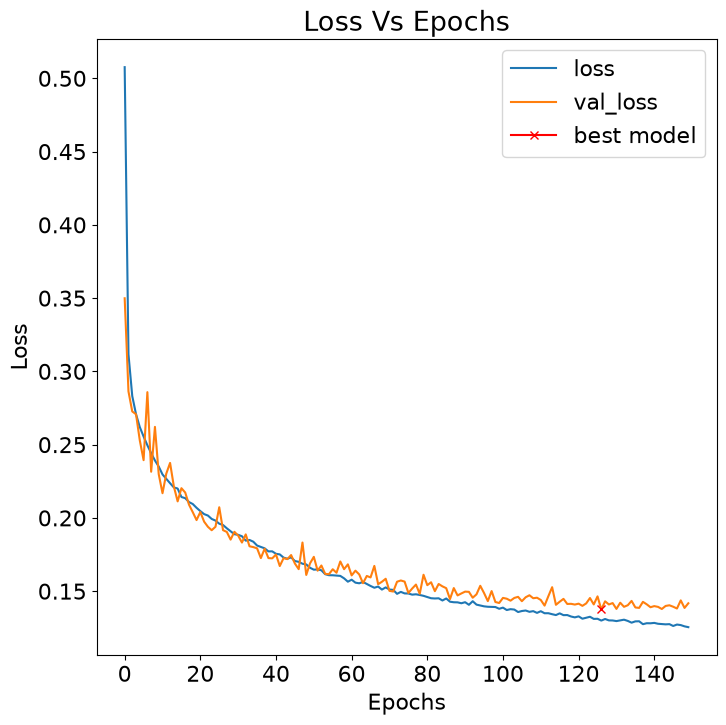

In [46]:
plt.figure(figsize=(8,8))
plt.title("Loss Vs Epochs")
plt.plot(train_losses, label="loss")
plt.plot(val_losses, label="val_loss")
plt.plot( np.argmin(val_losses), np.min(val_losses), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

## Avaliação

In [47]:
# Decimando o conjunto de teste para manter a coerência com o treino
print("Decimando x_test...")
x_test_70 = signal.resample(x_test, 70, axis=2)

# Passando para o Dataset e DataLoader
test_dataset = ImageDataset(x_test_70, y_test)
test_loader = DataLoader(test_dataset, batch_size=BATCH, shuffle=False)

Decimando x_test...


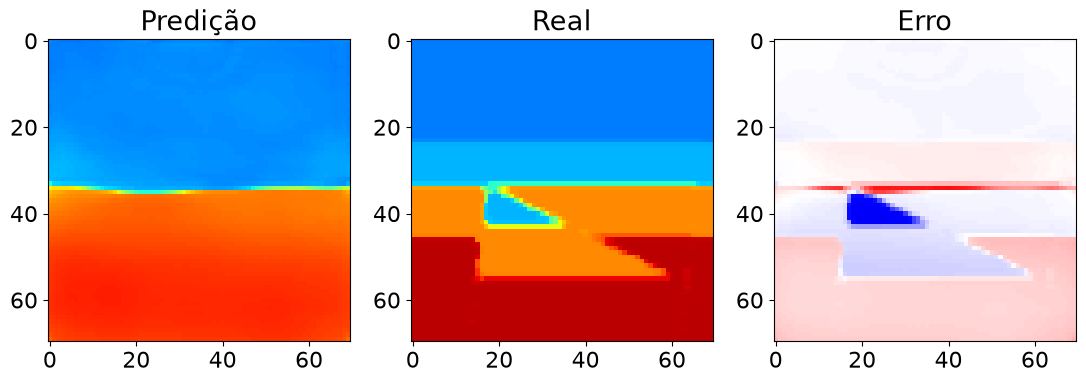

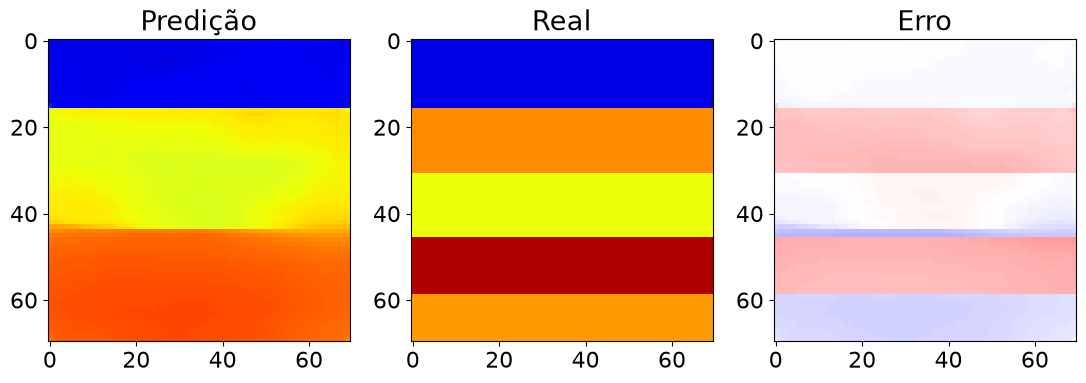

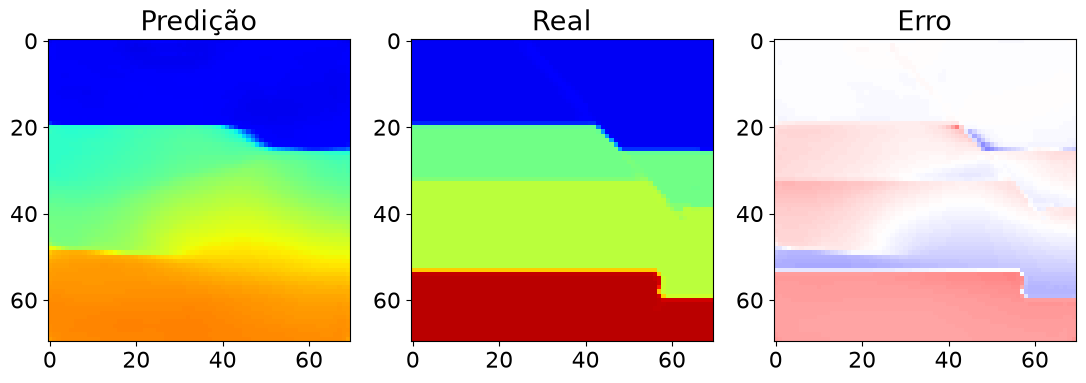

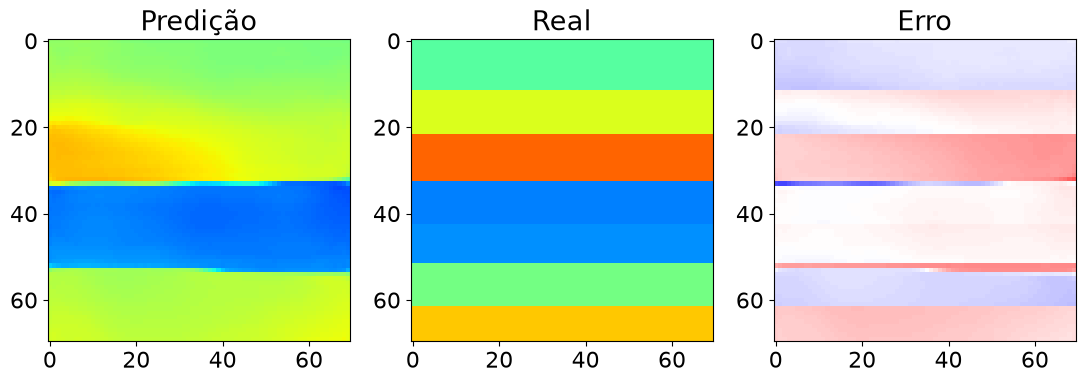

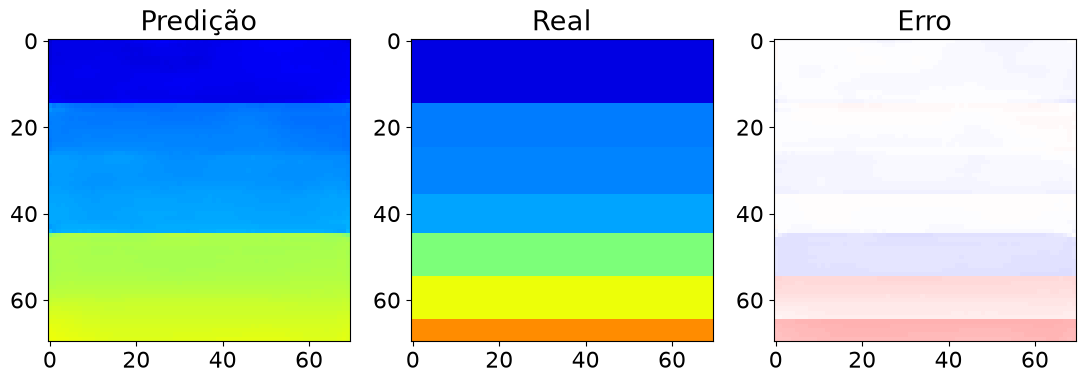

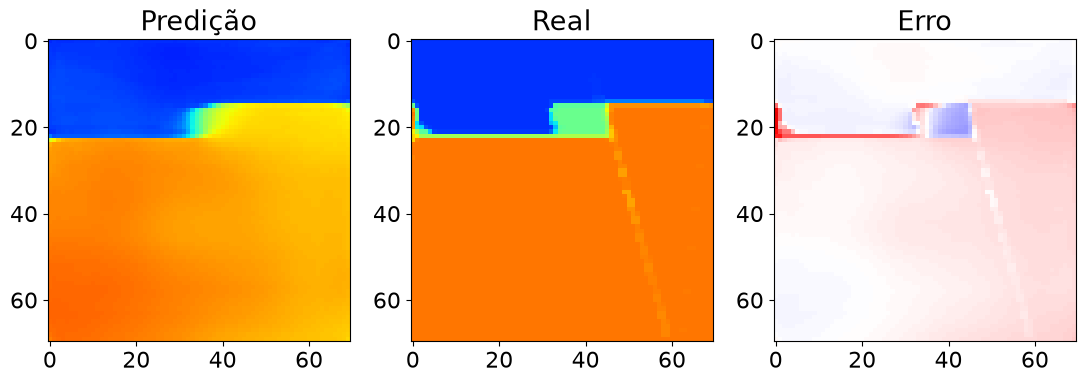

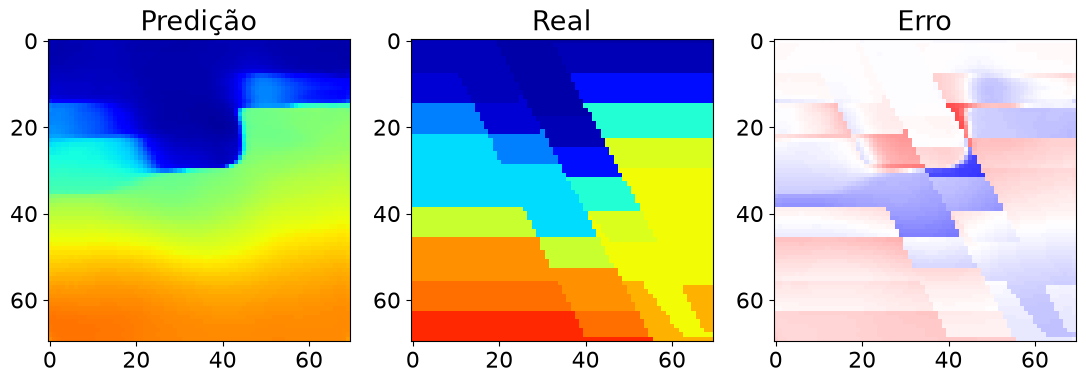

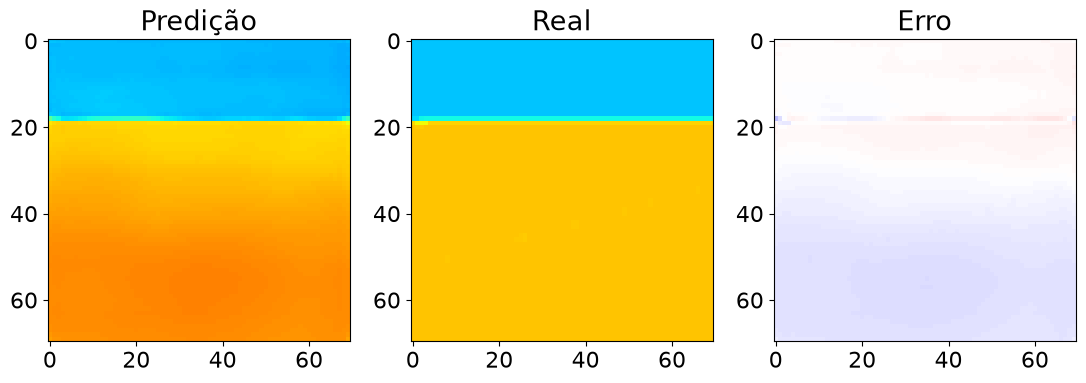

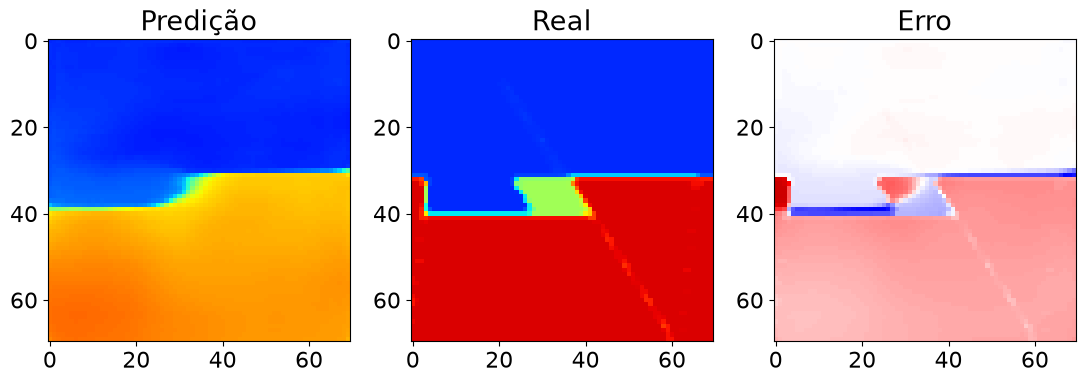

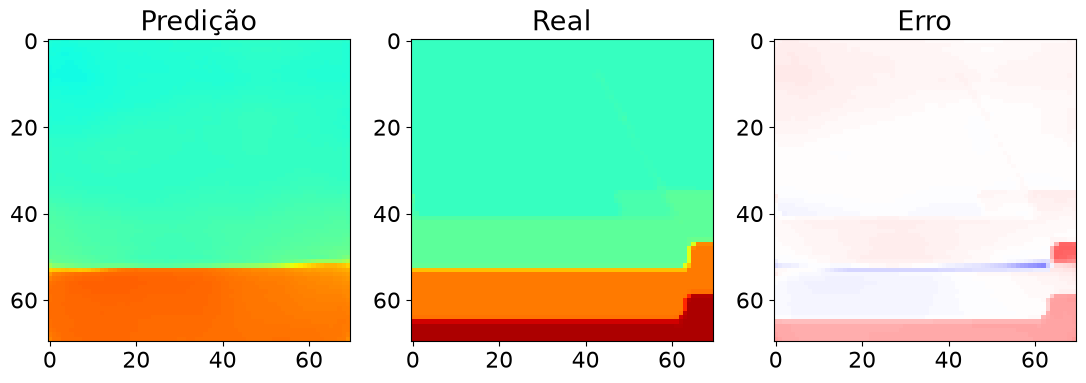

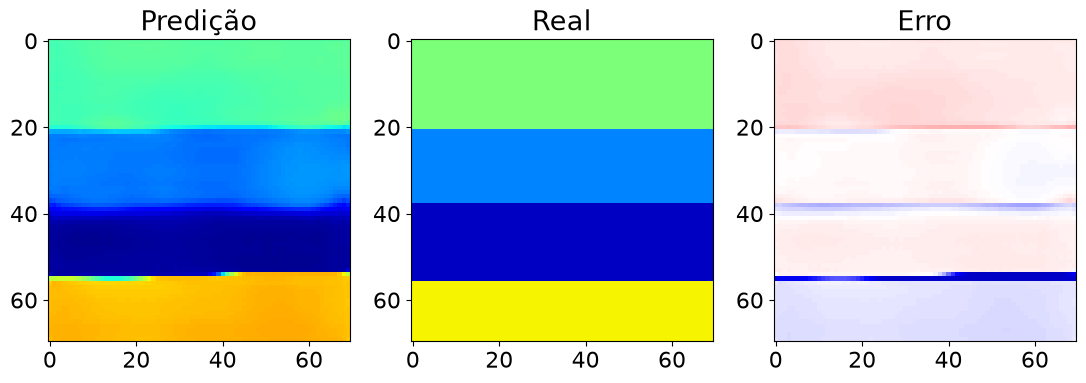

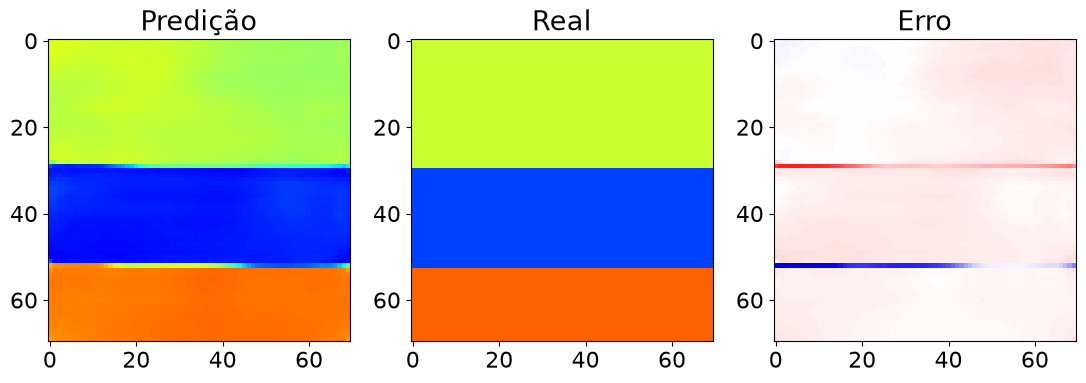

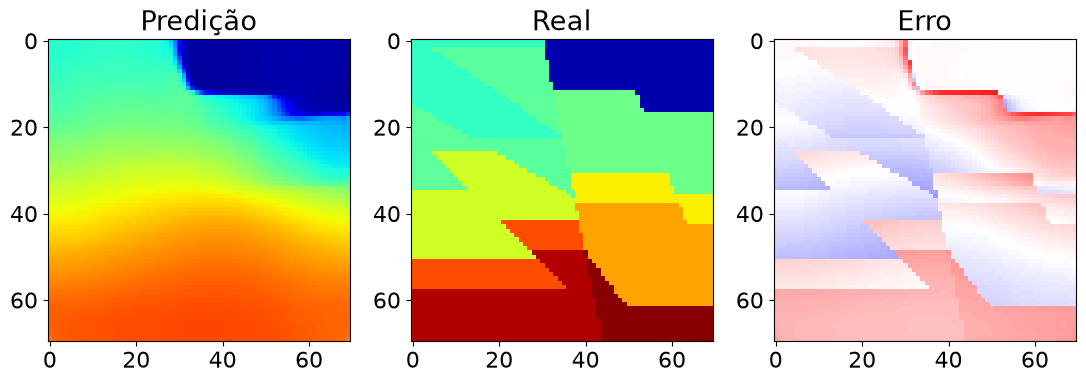

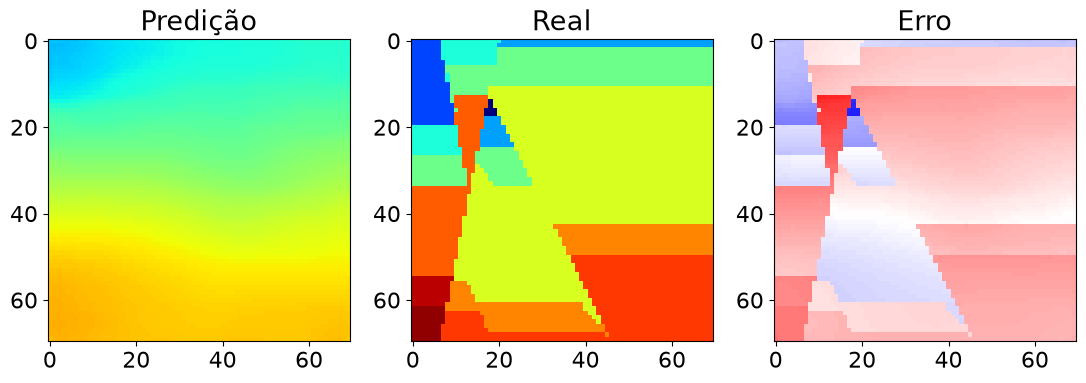

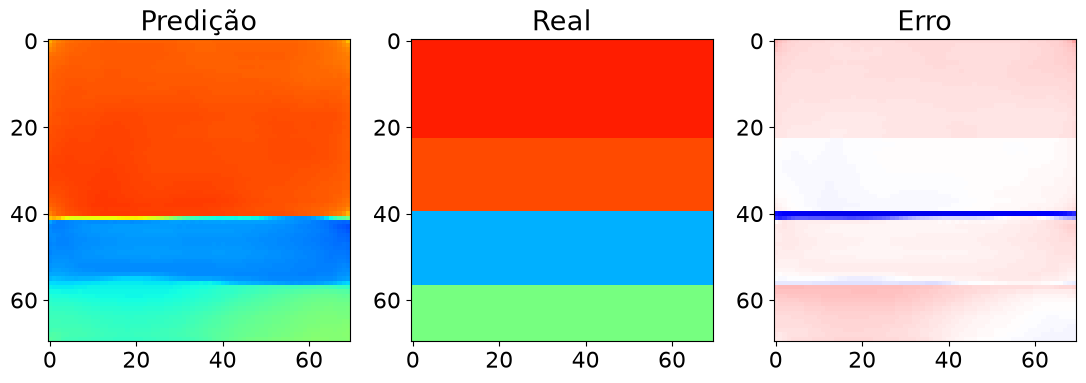

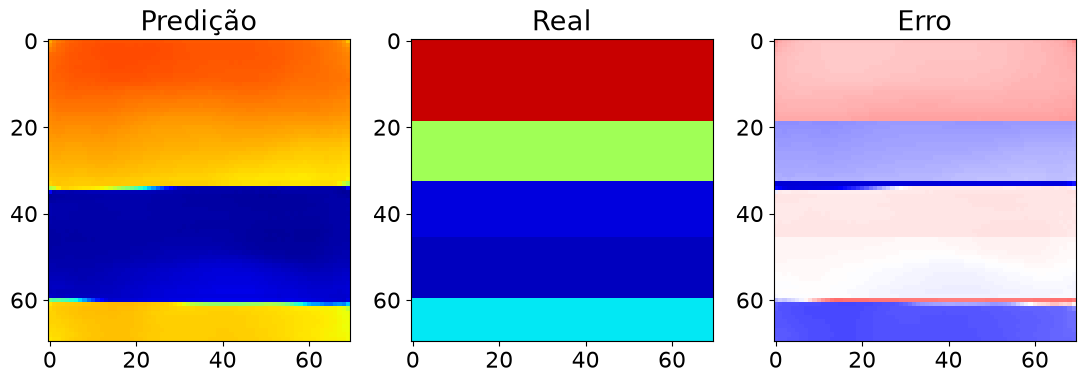

In [ ]:
model.load_state_dict(torch.load("model_unet.pth"))
model.eval()
pred = model(torch.tensor(x_test_70, dtype=torch.float32,device=device))
pred_cpu=pred.detach().cpu().numpy()

for i in range(len(x_test_70)):
    if i > 15:
        break

    n_image = i#np.random.randint(0,len(pred))
    fig = plt.figure(figsize=(32,8))
    gs = fig.add_gridspec(1, 7)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])

    ax1.imshow(pred_cpu[n_image,0,:,:],cmap="jet",vmin=0,vmax=1)
    ax1.set_title('Predição')
    ax2.imshow(y_test[n_image,0,:,:],cmap="jet",vmin=0,vmax=1)
    ax2.set_title('Real')
    ax3.imshow(y_test[n_image,0,:,:]-pred_cpu[n_image,0,:,:], cmap="seismic",vmin=-1,vmax=1)
    ax3.set_title('Erro')
    fig = plt.gcf()
    plt.show()

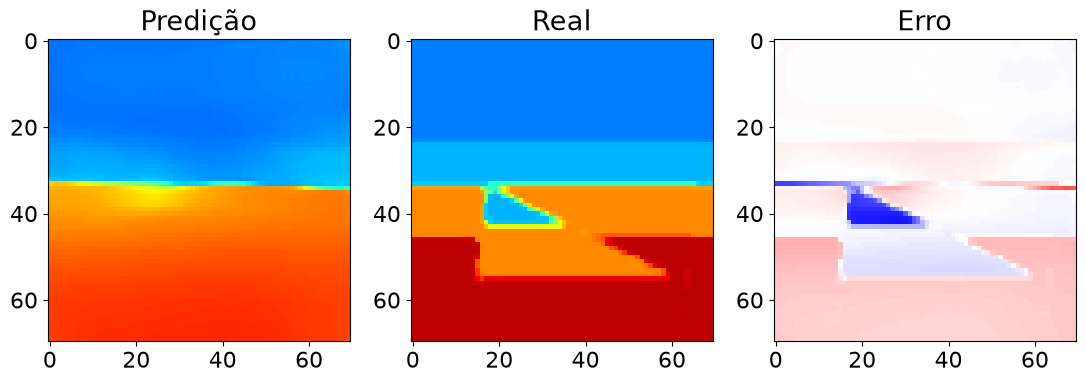

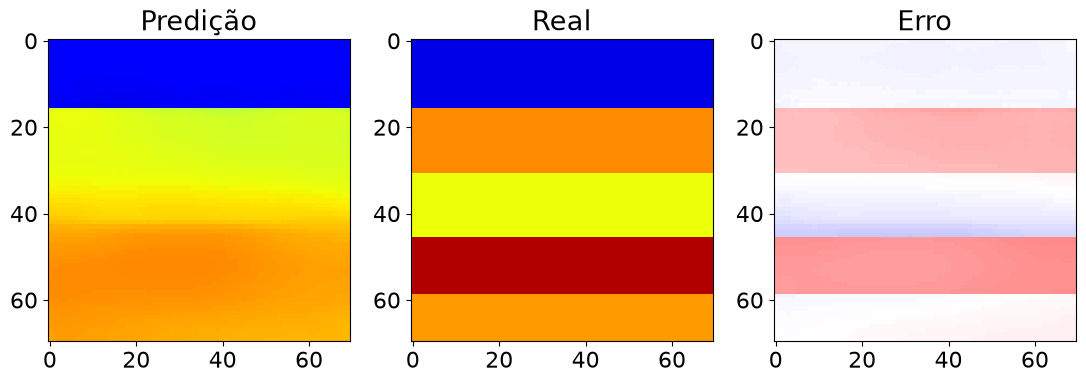

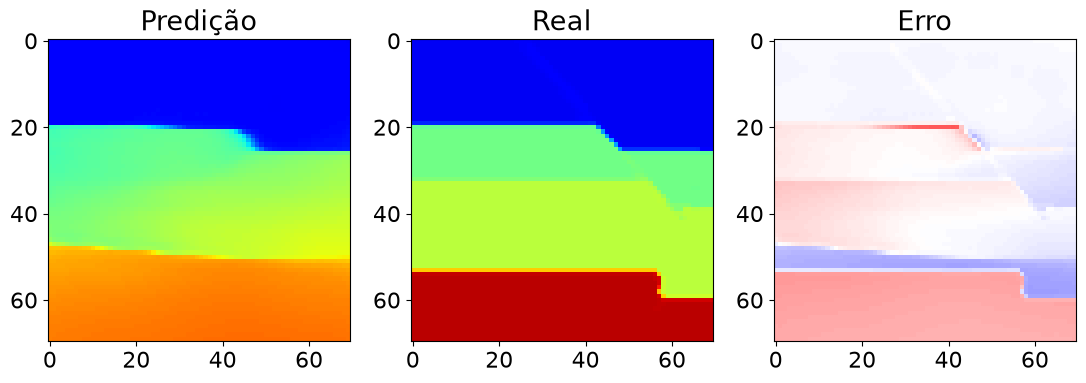

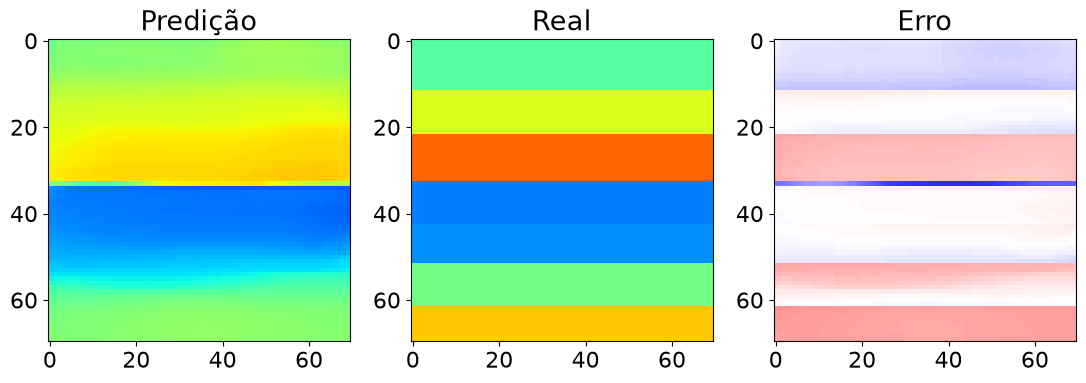

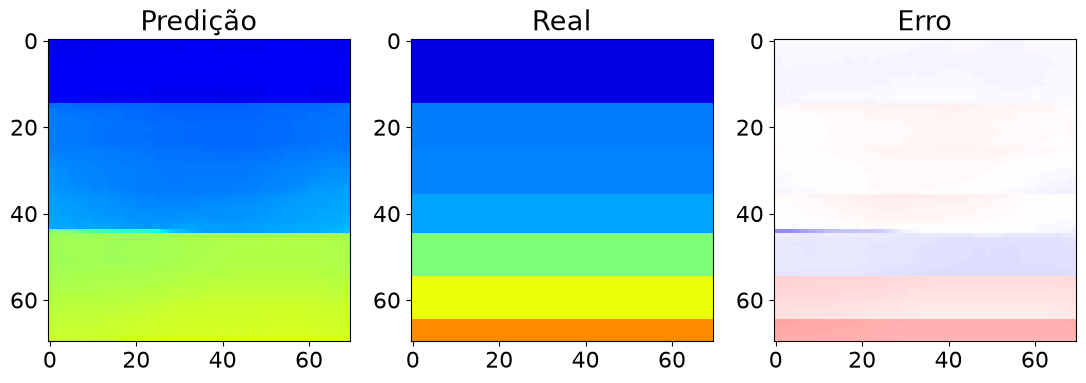

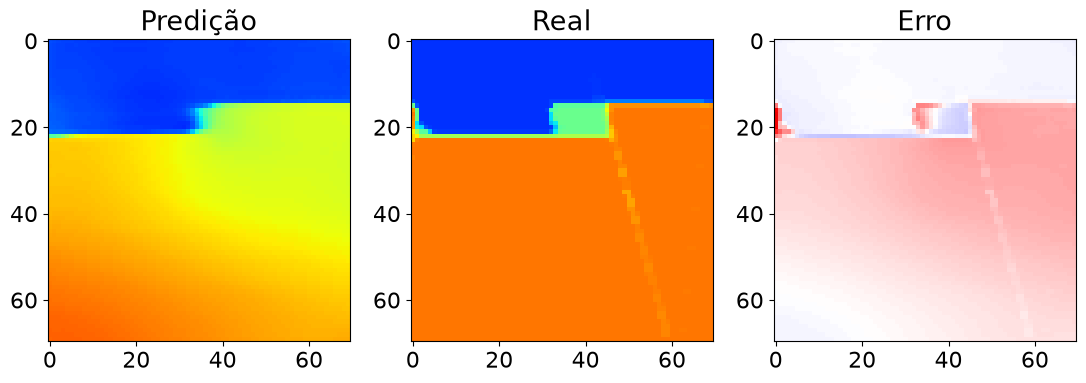

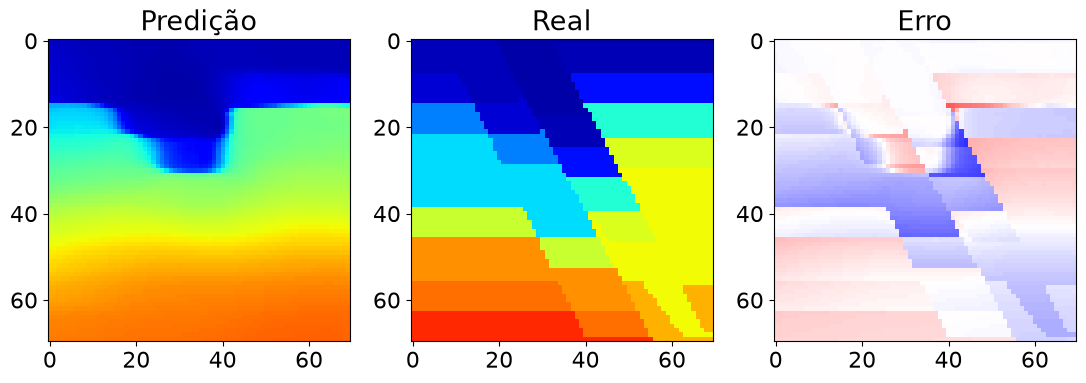

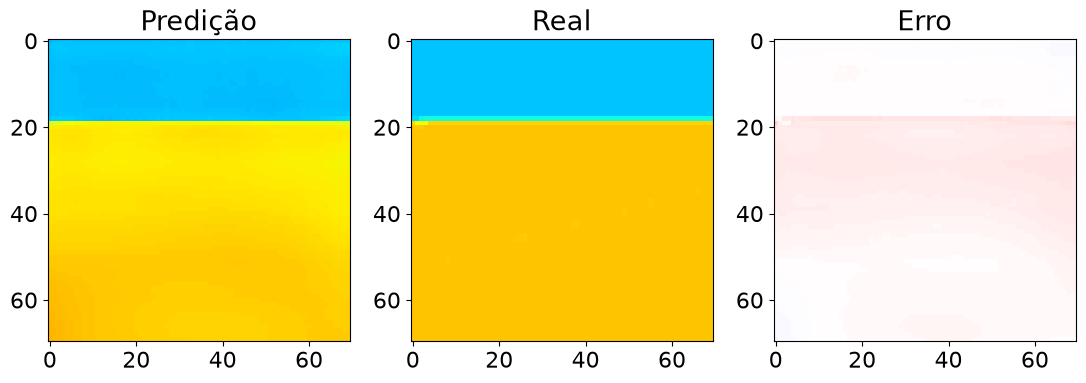

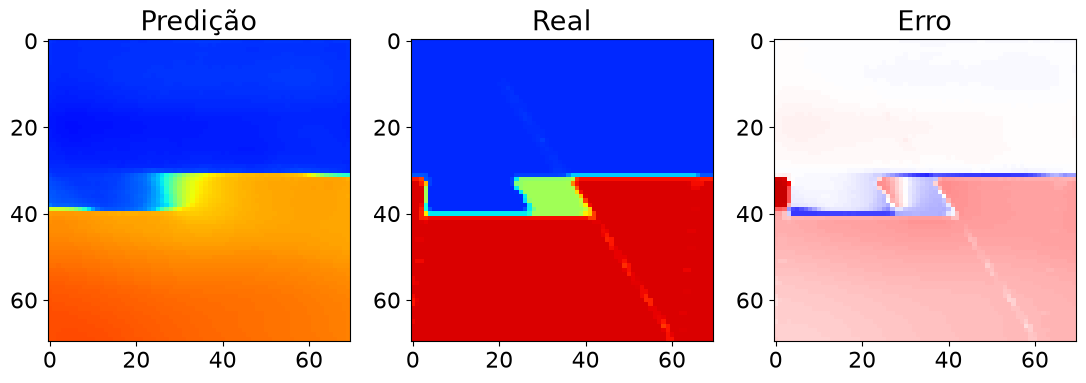

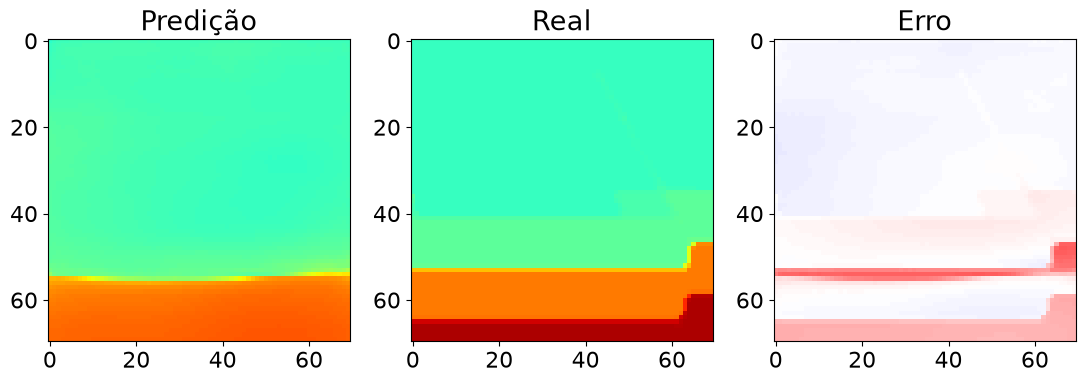

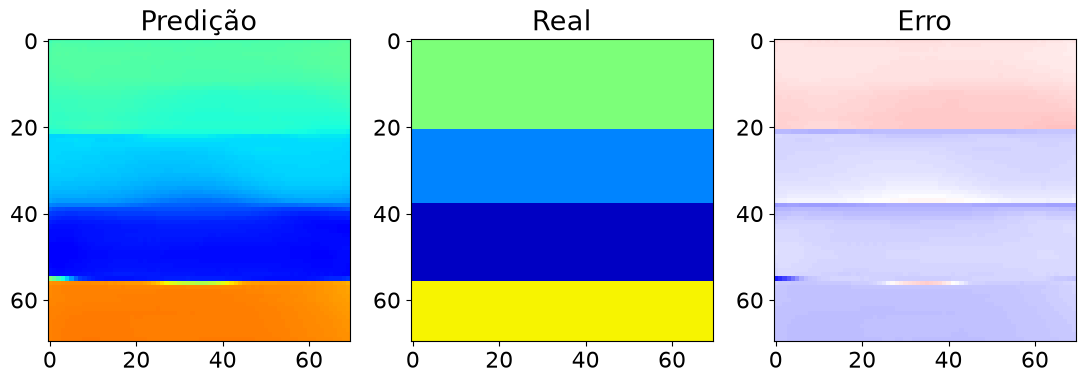

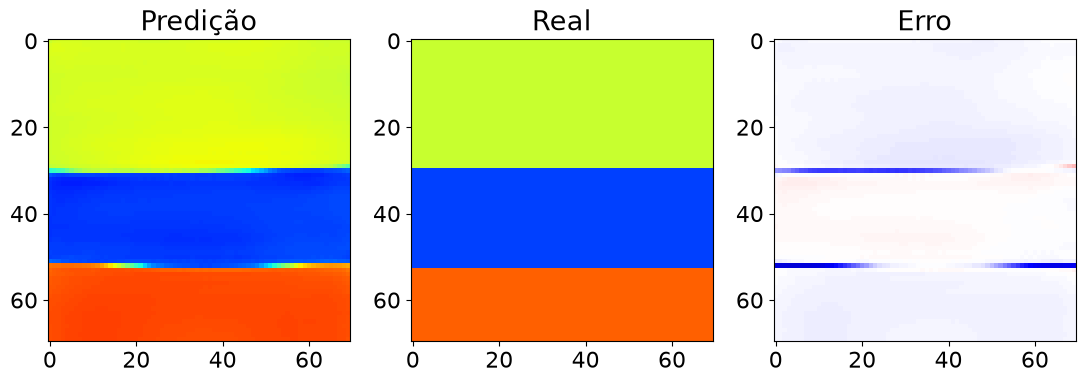

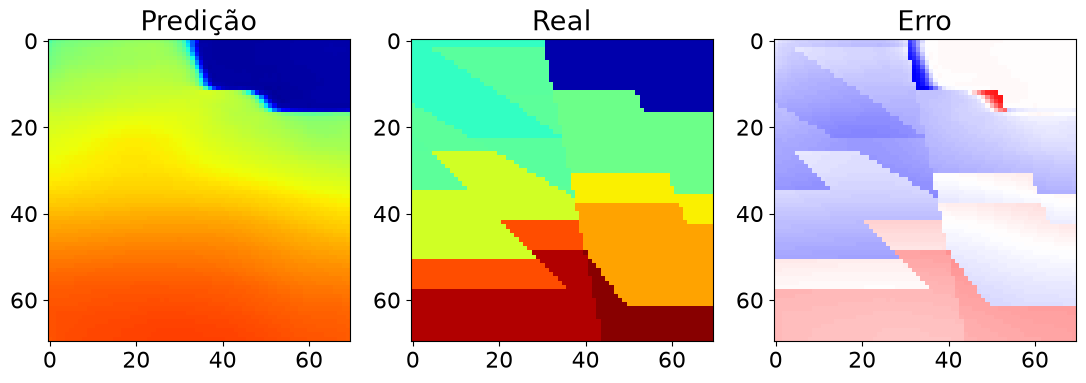

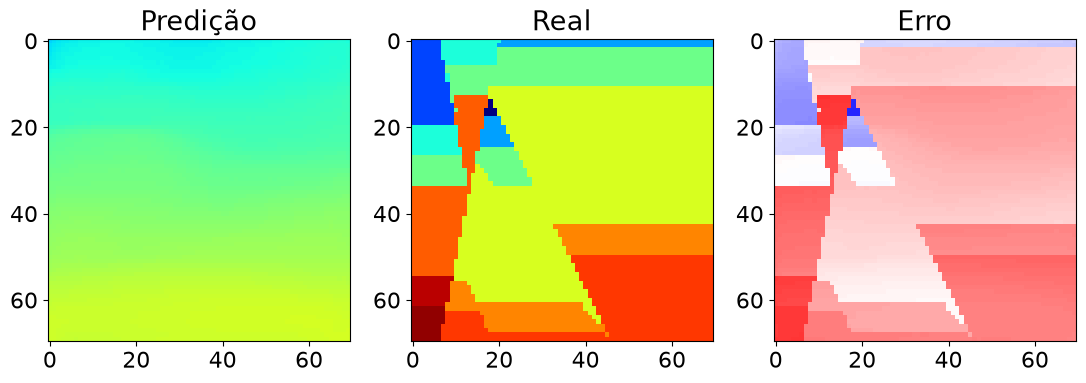

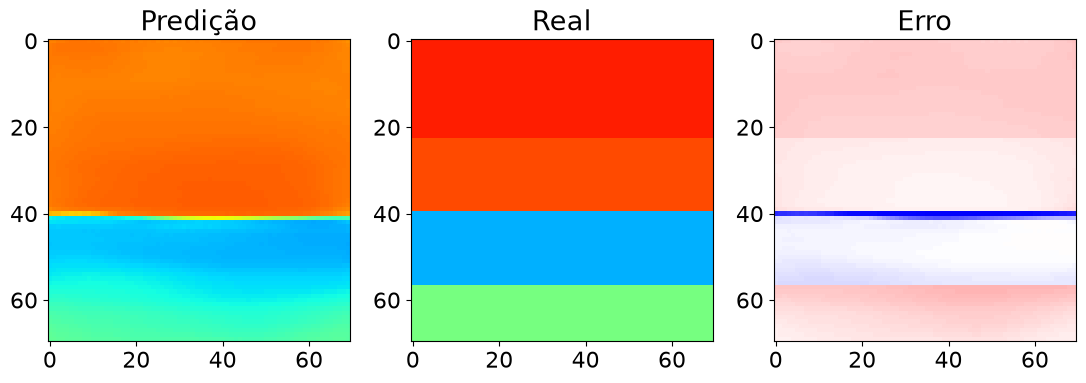

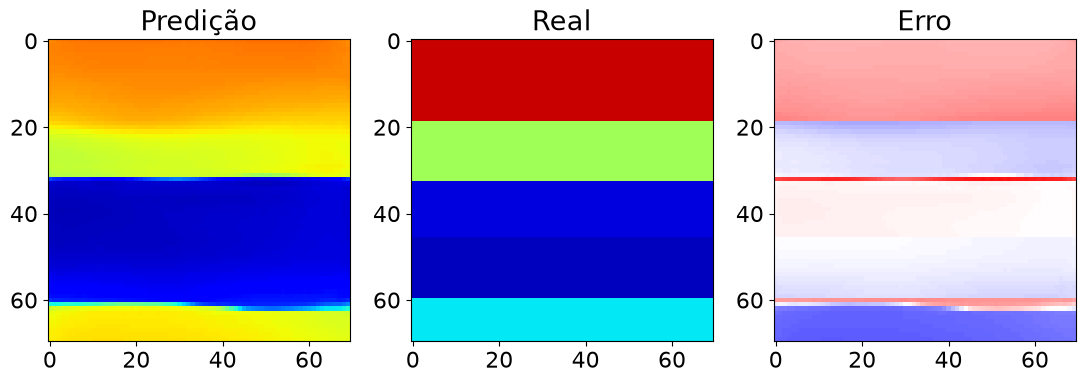

In [ ]:
model1 = UNetUpConvPad(in_channels=n_filters, n_filters=16,dropout=0.2,moment=0.2,batchnorm=True).to(device)

model1.load_state_dict(torch.load("model_fpad.pth"))
model1.eval()
pred = model1(torch.tensor(x_test_70, dtype=torch.float32,device=device))
pred_cpu=pred.detach().cpu().numpy()

for i in range(len(x_test_70)):
    if i > 15:
        break

    n_image = i#np.random.randint(0,len(pred))
    fig = plt.figure(figsize=(32,8))
    gs = fig.add_gridspec(1, 7)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])

    ax1.imshow(pred_cpu[n_image,0,:,:],cmap="jet",vmin=0,vmax=1)
    ax1.set_title('Predição')
    ax2.imshow(y_test[n_image,0,:,:],cmap="jet",vmin=0,vmax=1)
    ax2.set_title('Real')
    ax3.imshow(y_test[n_image,0,:,:]-pred_cpu[n_image,0,:,:], cmap="seismic",vmin=-1,vmax=1)
    ax3.set_title('Erro')
    fig = plt.gcf()
    plt.show()